# 06 - Validación end-to-end

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Cargar librerías
import platform
import sys
import unicodedata
from pathlib import Path
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
#Mostrar versiones
SEMILLA = 20260727

versiones = pd.DataFrame([
    {'componente': 'Python', 'version': platform.python_version()},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
    {'componente': 'matplotlib', 'version': matplotlib.__version__},
    {'componente': 'joblib', 'version': joblib.__version__},
])

display(versiones)

,componente,version
0,Python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,joblib,1.5.3


## 3. Rutas y artefactos

In [4]:
#Definir rutas
ruta_datasets = Path('../Datasets')
ruta_modelos = Path('../Modelos')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

archivos = {
    'perfiles': ruta_datasets / 'perfil_integral_usuario.csv',
    'transacciones': ruta_datasets / 'transacciones_contextualizadas.csv',
    'trayectorias': ruta_datasets / 'trayectorias_financieras.csv',
    'decisiones': ruta_datasets / 'decisiones_recomendaciones.csv',
    'modelo_usuario': ruta_modelos / '01_conocimiento_usuario.joblib',
    'modelo_transacciones': ruta_modelos / '02_clasificacion_transacciones.joblib',
    'modelo_estados': ruta_modelos / '04_estados_trayectoria.joblib',
    'modelo_recomendaciones': ruta_modelos / '05_motor_recomendaciones.joblib',
    'recurrencias': ruta_resultados / '03_recurrencias_observadas.csv',
    'tendencias': ruta_resultados / '03_tendencias_observadas.csv',
    'eventos': ruta_resultados / '03_eventos_inusuales.csv',
    'estados': ruta_resultados / '04_estados_trayectoria.csv',
    'metricas_estados': ruta_resultados / '04_metricas_modelo.csv',
    'recomendaciones': ruta_resultados / '05_recomendaciones.csv',
    'metricas_recomendaciones': ruta_resultados / '05_metricas_modelo.csv',
}

ruta_graficas.mkdir(parents=True, exist_ok=True)

In [5]:
#Revisar archivos
inventario = pd.DataFrame([
    {
        'artefacto': nombre,
        'ruta': str(ruta),
        'existe': ruta.exists(),
        'tamano_kb': round(ruta.stat().st_size / 1024, 2) if ruta.exists() else np.nan,
    }
    for nombre, ruta in archivos.items()
])

display(inventario)
assert inventario['existe'].all(), 'Faltan artefactos necesarios para ejecutar el recorrido completo'

,artefacto,ruta,existe,tamano_kb
0,perfiles,../Datasets/perfil_integral_usuario.csv,True,259.51
1,transacciones,../Datasets/transacciones_contextualizadas.csv,True,9659.39
2,trayectorias,../Datasets/trayectorias_financieras.csv,True,467.47
3,decisiones,../Datasets/decisiones_recomendaciones.csv,True,637.81
4,modelo_usuario,../Modelos/01_conocimiento_usuario.joblib,True,152.88
5,modelo_transacciones,../Modelos/02_clasificacion_transacciones.joblib,True,4930.72
6,modelo_estados,../Modelos/04_estados_trayectoria.joblib,True,4021.85
7,modelo_recomendaciones,../Modelos/05_motor_recomendaciones.joblib,True,4590.51
8,recurrencias,../Resultados/03_recurrencias_observadas.csv,True,2041.13
9,tendencias,../Resultados/03_tendencias_observadas.csv,True,28.90


## 4. Carga sin entrenamiento

In [6]:
#Cargar productos
perfiles = pd.read_csv(archivos['perfiles'])
transacciones = pd.read_csv(archivos['transacciones'])
trayectorias = pd.read_csv(archivos['trayectorias'])
decisiones = pd.read_csv(archivos['decisiones'])
recurrencias = pd.read_csv(archivos['recurrencias'])
tendencias = pd.read_csv(archivos['tendencias'])
eventos = pd.read_csv(archivos['eventos'])
estados = pd.read_csv(archivos['estados'])
metricas_estados = pd.read_csv(archivos['metricas_estados'])
recomendaciones = pd.read_csv(archivos['recomendaciones'])
metricas_recomendaciones = pd.read_csv(archivos['metricas_recomendaciones'])

artefacto_usuario = joblib.load(archivos['modelo_usuario'])
artefacto_transacciones = joblib.load(archivos['modelo_transacciones'])
artefacto_estados = joblib.load(archivos['modelo_estados'])
artefacto_recomendaciones = joblib.load(archivos['modelo_recomendaciones'])

modelo_categoria = artefacto_transacciones['modelo_categoria']
modelo_finalidad = artefacto_transacciones['modelo_finalidad']
modelo_regularidad_gastos = artefacto_transacciones['modelo_regularidad_gastos']
modelo_regularidad_ingresos = artefacto_transacciones['modelo_regularidad_ingresos']
modelo_confirmacion = artefacto_transacciones['modelo_confirmacion']
parejas_validas = artefacto_transacciones['parejas_validas']
escala_valor = artefacto_transacciones['escala_valor']
escala_proporcion = artefacto_transacciones['escala_proporcion']
UMBRAL_TRANSACCION = artefacto_transacciones['umbral_transaccion']
UMBRAL_CONFIRMACION = artefacto_transacciones['umbral_confirmacion']
UMBRAL_REGULARIDAD = artefacto_transacciones['umbral_regularidad']
vectorizador_descripciones_regularidad = artefacto_transacciones['vectorizador_descripciones_regularidad']
matriz_descripciones_regularidad = artefacto_transacciones['matriz_descripciones_regularidad']
descripciones_regularidad_entrenadas = artefacto_transacciones['descripciones_regularidad_entrenadas']

transacciones['fecha'] = pd.to_datetime(transacciones['fecha'], errors='coerce')
transacciones['valor'] = pd.to_numeric(transacciones['valor'], errors='coerce')

In [7]:
#Resumir carga
resumen_carga = pd.DataFrame([
    {'etapa': '01 conocimiento del usuario', 'producto': type(artefacto_usuario['modelo_actividad']).__name__, 'filas': len(perfiles)},
    {'etapa': '02 clasificación de transacciones', 'producto': type(artefacto_transacciones['modelo_categoria']).__name__, 'filas': len(transacciones)},
    {'etapa': '03 patrones temporales', 'producto': 'resultados auditables', 'filas': len(recurrencias) + len(tendencias) + len(eventos)},
    {'etapa': '04 estados de trayectoria', 'producto': type(artefacto_estados['modelo']).__name__, 'filas': len(estados)},
    {'etapa': '05 recomendaciones', 'producto': type(artefacto_recomendaciones['modelo']).__name__, 'filas': len(recomendaciones)},
])

display(resumen_carga)

,etapa,producto,filas
0,01 conocimiento del usuario,Pipeline,200
1,02 clasificación de transacciones,Pipeline,17284
2,03 patrones temporales,resultados auditables,9944
3,04 estados de trayectoria,Pipeline,200
4,05 recomendaciones,Pipeline,200


## 5. Contratos entre etapas

In [8]:
#Validar claves
claves_requeridas = {
    'usuario': ['modelo_actividad', 'vectorizador_catalogo', 'matriz_catalogo', 'umbral_alcance'],
    'transacciones': ['modelo_categoria', 'modelo_finalidad', 'modelo_regularidad_gastos', 'modelo_regularidad_ingresos', 'modelo_confirmacion', 'escala_valor', 'escala_proporcion', 'columnas_historial', 'umbral_regularidad', 'vectorizador_descripciones_regularidad', 'matriz_descripciones_regularidad'],
    'estados': ['modelo', 'variables_modelo', 'variables_contexto', 'umbral_confianza', 'clases'],
    'recomendaciones': ['modelo', 'variables_modelo', 'catalogo_recomendaciones', 'guardas_eticas', 'version_modelo_estados'],
}

artefactos_modelo = {
    'usuario': artefacto_usuario,
    'transacciones': artefacto_transacciones,
    'estados': artefacto_estados,
    'recomendaciones': artefacto_recomendaciones,
}

revision_claves = pd.DataFrame([
    {
        'artefacto': nombre,
        'claves_faltantes': ' | '.join(sorted(set(claves_requeridas[nombre]) - set(artefacto))),
    }
    for nombre, artefacto in artefactos_modelo.items()
])
versiones_esperadas = {
    'usuario': 'fincoach_usuario_mvp_v2',
    'transacciones': 'fincoach_transacciones_mvp_v3',
    'estados': 'fincoach_estados_trayectoria_mvp_v3',
    'recomendaciones': 'fincoach_recomendaciones_mvp_v3',
}
revision_versiones = pd.DataFrame([
    {
        'artefacto': nombre,
        'version_esperada': versiones_esperadas[nombre],
        'version_encontrada': artefacto.get('version_modelo', 'no_disponible'),
        'coincide': artefacto.get('version_modelo') == versiones_esperadas[nombre],
    }
    for nombre, artefacto in artefactos_modelo.items()
])

display(revision_claves)
display(revision_versiones)
assert revision_claves['claves_faltantes'].eq('').all(), 'Un modelo no cumple su contrato serializado'
assert revision_versiones['coincide'].all(), 'Un artefacto pertenece a una versión anterior del pipeline'
assert artefacto_recomendaciones['version_modelo_estados'] == artefacto_estados['version_modelo'], 'El modelo 05 no corresponde con el modelo 04 actual'

,artefacto,claves_faltantes
0,usuario,
1,transacciones,
2,estados,
3,recomendaciones,


,artefacto,version_esperada,version_encontrada,coincide
0,usuario,fincoach_usuario_mvp_v2,fincoach_usuario_mvp_v2,True
1,transacciones,fincoach_transacciones_mvp_v3,fincoach_transacciones_mvp_v3,True
2,estados,fincoach_estados_trayectoria_mvp_v3,fincoach_estados_trayectoria_mvp_v3,True
3,recomendaciones,fincoach_recomendaciones_mvp_v3,fincoach_recomendaciones_mvp_v3,True


In [9]:
#Construir trazabilidad
conteo_transacciones = transacciones.groupby('perfil_id').size().rename('transacciones_disponibles')
recurrencias_confirmadas = recurrencias.loc[
    recurrencias['estado_recurrencia'].eq('recurrencia_observada')
].copy()
conteo_recurrencias = recurrencias_confirmadas.groupby('perfil_id').size().rename('recurrencias_recalculadas')
conteo_recurrencias_tipo = recurrencias_confirmadas.pivot_table(
    index='perfil_id',
    columns='regularidad_financiera_dataset',
    values='descripcion_normalizada',
    aggfunc='size',
    fill_value=0,
).reindex(columns=['fijo', 'variable', 'estacional'], fill_value=0).rename(columns={
    'fijo': 'recurrencias_fijas_recalculadas',
    'variable': 'recurrencias_variables_recalculadas',
    'estacional': 'recurrencias_estacionales_recalculadas',
})
conteo_eventos = eventos.groupby('perfil_id').size().rename('eventos_inusuales_observados')

base_perfiles = perfiles[[
    'perfil_id',
    'descripcion_visible',
    'actividad_principal_declarada',
    'actividad_1_familia',
    'estado_ingreso_actual',
    'objetivo_proximo',
    'estado_alcance_mvp',
    'particion',
    'es_sintetico',
]].rename(columns={
    'particion': 'particion_perfil',
    'estado_alcance_mvp': 'alcance_perfil',
})

base_estados = estados[[
    'perfil_id',
    'ventana_id',
    'periodo_desde',
    'periodo_hasta',
    'estado_modelo',
    'estado_reto',
    'estado_calculo_modelo',
    'confianza_pct',
    'recurrencias_observadas',
    'recurrencias_fijas_observadas',
    'recurrencias_variables_observadas',
    'recurrencias_estacionales_observadas',
    'particion',
]].rename(columns={'particion': 'particion_estado'})

base_recomendaciones = recomendaciones[[
    'perfil_id',
    'ventana_id',
    'periodo_desde',
    'periodo_hasta',
    'estado_trayectoria',
    'estado_motor',
    'recomendacion_id',
    'decision',
    'fuente_seleccion',
    'requiere_confirmacion',
    'revision_humana',
    'razon_decision',
    'motivos',
    'guardas_aplicadas',
]].rename(columns={
    'ventana_id': 'ventana_recomendacion',
    'periodo_desde': 'periodo_desde_recomendacion',
    'periodo_hasta': 'periodo_hasta_recomendacion',
})

trazabilidad = base_perfiles.merge(base_estados, on='perfil_id', how='left', validate='one_to_one')
trazabilidad = trazabilidad.merge(base_recomendaciones, on='perfil_id', how='left', validate='one_to_one')
trazabilidad = trazabilidad.join(conteo_transacciones, on='perfil_id')
trazabilidad = trazabilidad.join(conteo_recurrencias, on='perfil_id')
trazabilidad = trazabilidad.join(conteo_recurrencias_tipo, on='perfil_id')
trazabilidad = trazabilidad.join(conteo_eventos, on='perfil_id')
columnas_recalculadas = [
    'recurrencias_recalculadas',
    'recurrencias_fijas_recalculadas',
    'recurrencias_variables_recalculadas',
    'recurrencias_estacionales_recalculadas',
    'eventos_inusuales_observados',
]
trazabilidad[columnas_recalculadas] = trazabilidad[columnas_recalculadas].fillna(0).astype(int)

In [10]:
#Comprobar integración
trazabilidad['estado_coherente'] = trazabilidad['estado_modelo'].eq(trazabilidad['estado_trayectoria'])
trazabilidad['ventana_coherente'] = trazabilidad['ventana_id'].eq(trazabilidad['ventana_recomendacion'])
trazabilidad['periodo_coherente'] = (
    trazabilidad['periodo_desde'].eq(trazabilidad['periodo_desde_recomendacion'])
    & trazabilidad['periodo_hasta'].eq(trazabilidad['periodo_hasta_recomendacion'])
)

trazabilidad['particion_coherente'] = trazabilidad['particion_perfil'].eq(trazabilidad['particion_estado'])
trazabilidad['recurrencias_coherentes'] = (
    trazabilidad['recurrencias_observadas'].eq(trazabilidad['recurrencias_recalculadas'])
    & trazabilidad['recurrencias_fijas_observadas'].eq(trazabilidad['recurrencias_fijas_recalculadas'])
    & trazabilidad['recurrencias_variables_observadas'].eq(trazabilidad['recurrencias_variables_recalculadas'])
    & trazabilidad['recurrencias_estacionales_observadas'].eq(trazabilidad['recurrencias_estacionales_recalculadas'])
)
trazabilidad['salida_motor_valida'] = trazabilidad['estado_motor'].isin(['recomendacion_disponible', 'abstencion'])
trazabilidad['salida_recomendacion_coherente'] = (
    trazabilidad['estado_motor'].eq('recomendacion_disponible')
    & trazabilidad['recomendacion_id'].ne('no_disponible')
) | (
    trazabilidad['estado_motor'].eq('abstencion')
    & trazabilidad['recomendacion_id'].eq('no_disponible')
)
trazabilidad['recorrido_completo'] = (
    trazabilidad['salida_motor_valida']
    & trazabilidad['salida_recomendacion_coherente']
    & trazabilidad['transacciones_disponibles'].gt(0)
    & trazabilidad['estado_coherente']
    & trazabilidad['ventana_coherente']
    & trazabilidad['periodo_coherente']
    & trazabilidad['particion_coherente']
    & trazabilidad['recurrencias_coherentes']
)

controles_integracion = pd.DataFrame([
    {'control': 'identificadores de perfil únicos', 'errores': int(perfiles['perfil_id'].duplicated().sum())},
    {'control': 'un estado actual por perfil', 'errores': int(estados['perfil_id'].duplicated().sum())},
    {'control': 'una recomendación actual por perfil', 'errores': int(recomendaciones['perfil_id'].duplicated().sum())},
    {'control': 'perfiles sin transacciones', 'errores': int(trazabilidad['transacciones_disponibles'].isna().sum())},
    {'control': 'estado inconsistente', 'errores': int((~trazabilidad['estado_coherente']).sum())},
    {'control': 'ventana inconsistente', 'errores': int((~trazabilidad['ventana_coherente']).sum())},
    {'control': 'periodo inconsistente', 'errores': int((~trazabilidad['periodo_coherente']).sum())},
    {'control': 'partición inconsistente', 'errores': int((~trazabilidad['particion_coherente']).sum())},
    {'control': 'recurrencias inconsistentes', 'errores': int((~trazabilidad['recurrencias_coherentes']).sum())},
    {'control': 'salida del motor inválida', 'errores': int((~trazabilidad['salida_motor_valida']).sum())},
    {'control': 'recomendación o abstención inconsistente', 'errores': int((~trazabilidad['salida_recomendacion_coherente']).sum())},
])

display(controles_integracion)
assert controles_integracion['errores'].eq(0).all(), 'El recorrido end-to-end contiene contratos inconsistentes'

,control,errores
0,identificadores de perfil únicos,0
1,un estado actual por perfil,0
2,una recomendación actual por perfil,0
3,perfiles sin transacciones,0
4,estado inconsistente,0
5,ventana inconsistente,0
6,periodo inconsistente,0
7,partición inconsistente,0
8,recurrencias inconsistentes,0
9,salida del motor inválida,0


## 6. Controles éticos y de alcance

In [11]:
#Auditar guardas
ultima_trayectoria = trayectorias.sort_values(['perfil_id', 'fecha_corte']).groupby('perfil_id').tail(1)
auditoria_recomendaciones = recomendaciones.merge(
    estados[['perfil_id', 'estado_calculo_modelo', 'estado_ingreso_actual', 'objetivo_declarado']],
    on='perfil_id',
    how='left',
    validate='one_to_one',
).merge(
    ultima_trayectoria[['perfil_id', 'deuda_final', 'cobertura_esencial_L_meses']],
    on='perfil_id',
    how='left',
    validate='one_to_one',
)
catalogo_valido = {item['recomendacion_id'] for item in artefacto_recomendaciones['catalogo_recomendaciones']} | {'no_disponible'}
mascara_disponible = auditoria_recomendaciones['estado_motor'].eq('recomendacion_disponible')
mascara_abstencion = auditoria_recomendaciones['estado_motor'].eq('abstencion')
mascara_critica = auditoria_recomendaciones['estado_trayectoria'].eq('situacion_critica')
mascara_fragilidad = auditoria_recomendaciones['estado_trayectoria'].eq('fragilidad_sostenida')
mascara_sin_ingresos = auditoria_recomendaciones['estado_ingreso_actual'].eq('sin_ingresos')
mascara_con_deuda = auditoria_recomendaciones['deuda_final'].gt(0)
mascara_hobbies = auditoria_recomendaciones['hobbies_considerados'].fillna('no_declarado').ne('no_declarado')
guarda_hobbies = auditoria_recomendaciones['guardas_aplicadas'].fillna('').apply(
    lambda valor: 'hobbies_no_eliminados_automaticamente' in str(valor)
)

controles_eticos = pd.DataFrame([
    {'control': 'abstención cuando el estado no es calculable', 'errores': int((auditoria_recomendaciones['estado_calculo_modelo'].ne('calculado') & ~mascara_abstencion).sum())},
    {'control': 'sin ingresos con recursos protegidos', 'errores': int(auditoria_recomendaciones.loc[mascara_disponible & mascara_sin_ingresos, 'recomendacion_id'].ne('REC_CUIDAR_RECURSOS_SIN_INGRESO').sum())},
    {'control': 'situación crítica con apoyo y contención', 'errores': int(auditoria_recomendaciones.loc[mascara_disponible & mascara_critica & ~mascara_sin_ingresos, 'recomendacion_id'].ne('REC_BUSCAR_APOYO_Y_CONTENER').sum())},
    {'control': 'fragilidad con deuda protegida', 'errores': int(auditoria_recomendaciones.loc[mascara_disponible & mascara_fragilidad & mascara_con_deuda, 'recomendacion_id'].ne('REC_PROTEGER_ESENCIALES_Y_DEUDA').sum())},
    {'control': 'fragilidad sin deuda con esenciales protegidos', 'errores': int(auditoria_recomendaciones.loc[mascara_disponible & mascara_fragilidad & ~mascara_con_deuda, 'recomendacion_id'].ne('REC_PROTEGER_ESENCIALES').sum())},
    {'control': 'hobbies declarados conservados', 'errores': int((mascara_disponible & mascara_hobbies & ~guarda_hobbies).sum())},
    {'control': 'identificadores dentro del catálogo', 'errores': int((~auditoria_recomendaciones['recomendacion_id'].isin(catalogo_valido)).sum())},
    {'control': 'fuente de selección declarada', 'errores': int(auditoria_recomendaciones['fuente_seleccion'].isna().sum())},
])

display(controles_eticos)
assert controles_eticos['errores'].eq(0).all(), 'Una guarda ética dejó de cumplirse'

,control,errores
0,abstención cuando el estado no es calculable,0
1,sin ingresos con recursos protegidos,0
2,situación crítica con apoyo y contención,0
3,fragilidad con deuda protegida,0
4,fragilidad sin deuda con esenciales protegidos,0
5,hobbies declarados conservados,0
6,identificadores dentro del catálogo,0
7,fuente de selección declarada,0


## 7. Inferencia integrada

In [12]:
#Normalizar entradas
def normalizar_texto(texto):
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    texto = ''.join(caracter for caracter in texto if not unicodedata.combining(caracter))
    texto = texto.replace('_', ' ').replace('-', ' ')
    return ' '.join(texto.split())

def valor_texto(valor, reemplazo='no_declarado'):
    if pd.isna(valor) or not str(valor).strip():
        return reemplazo
    return str(valor).strip()

In [13]:
#Preparar contexto
def puntuar_actividad_usuario(texto):
    modelo = artefacto_usuario['modelo_actividad']
    probabilidades = dict(zip(modelo.classes_, modelo.predict_proba([texto])[0]))
    vector = artefacto_usuario['vectorizador_catalogo'].transform([texto])
    similitudes = cosine_similarity(vector, artefacto_usuario['matriz_catalogo'])[0]
    familias = artefacto_usuario['familias_catalogo']
    resultados = []

    for actividad in modelo.classes_:
        similitud = float(similitudes[familias == actividad].max())
        probabilidad = float(probabilidades[actividad])
        confianza = (
            artefacto_usuario['peso_modelo'] * probabilidad
            + artefacto_usuario['peso_catalogo'] * similitud
        )
        resultados.append({'actividad': str(actividad), 'confianza': confianza})

    return sorted(resultados, key=lambda resultado: resultado['confianza'], reverse=True)

def clasificar_hobbies_usuario(hobbies):
    if isinstance(hobbies, (list, tuple, set)):
        texto = ' | '.join(str(hobby) for hobby in hobbies)
    else:
        texto = str(hobbies or '')

    texto_normalizado = normalizar_texto(texto)
    palabras = set(texto_normalizado.replace('|', ' ').replace(',', ' ').replace(';', ' ').split())
    encontrados = []

    for hobby, variantes in artefacto_usuario['variantes_hobbies'].items():
        for variante in variantes:
            variante_normalizada = normalizar_texto(variante)
            coincide = variante_normalizada in texto_normalizado if ' ' in variante_normalizada else variante_normalizada in palabras
            if coincide:
                encontrados.append(hobby)
                break

    return encontrados if encontrados else ['no_declarado']

In [14]:
#Conocer usuario
def conocer_usuario(test_usuario):
    if not isinstance(test_usuario, dict):
        raise TypeError('test_usuario debe ser un diccionario')

    actividad_declarada = str(
        test_usuario.get('actividad_principal_declarada')
        or test_usuario.get('ingreso_principal')
        or ''
    ).strip()
    if not actividad_declarada:
        raise ValueError('actividad_principal_declarada debe contener texto')

    resultados = puntuar_actividad_usuario(actividad_declarada)
    mejor_resultado = resultados[0]
    confianza = mejor_resultado['confianza']
    dentro_mvp = confianza >= artefacto_usuario['umbral_alcance']
    actividad = mejor_resultado['actividad'] if dentro_mvp else 'no_disponible'

    ingreso_mensual = float(test_usuario.get('ingreso_mensual_neto', 0))
    if ingreso_mensual < 0:
        raise ValueError('ingreso_mensual_neto no puede ser negativo')
    modalidad = str(test_usuario.get('modalidad_ingreso_principal', '')).strip().lower()
    estado_ingreso = 'sin_ingresos' if ingreso_mensual == 0 else modalidad
    if estado_ingreso not in artefacto_usuario['modalidades_ingreso']:
        raise ValueError('modalidad_ingreso_principal no es válida')

    ingreso_adicional = str(test_usuario.get('ingreso_adicional', '') or '').strip()
    actividad_secundaria = 'no_declarada'
    if test_usuario.get('tiene_ingreso_adicional') and ingreso_adicional:
        resultado_secundario = puntuar_actividad_usuario(ingreso_adicional)[0]
        actividad_secundaria = resultado_secundario['actividad'] if resultado_secundario['confianza'] >= artefacto_usuario['umbral_alcance'] else 'fuera_del_mvp'

    tipos_deuda = test_usuario.get('tipos_deuda', [])
    if isinstance(tipos_deuda, (list, tuple, set)):
        tipos_deuda = ' | '.join(str(deuda) for deuda in tipos_deuda)

    return {
        'estado_alcance_mvp': 'dentro_del_mvp' if dentro_mvp else 'no_disponible',
        'actividad_principal': actividad,
        'actividad_secundaria': actividad_secundaria,
        'estado_ingreso_actual': estado_ingreso,
        'ingreso_mensual_neto': ingreso_mensual,
        'hobbies_intereses': clasificar_hobbies_usuario(test_usuario.get('hobbies', [])),
        'meta': str(test_usuario.get('objetivo_proximo', '') or 'no_declarada').strip(),
        'responsabilidad': str(test_usuario.get('responsabilidad_financiera', '') or 'no_declarada').strip(),
        'tipos_deuda': str(tipos_deuda or 'sin_deuda'),
        'nivel_endeudamiento_pct': test_usuario.get('nivel_endeudamiento_pct'),
        'habito_ahorro': str(test_usuario.get('habito_ahorro', 'no_declarado')).strip().lower(),
        'confianza_usuario_pct': round(confianza * 100, 2),
        'motivo': 'Actividad reconocida dentro del catálogo cerrado del MVP' if dentro_mvp else 'La actividad no alcanzó el 50% dentro del catálogo cerrado del MVP',
    }

In [15]:
#Preparar movimiento
def construir_texto_modelo(fila):
    partes = [
        'transaccion {}'.format(valor_texto(fila['descripcion_normalizada'])),
        'nota {}'.format(valor_texto(fila['nota_usuario'])),
        'direccion {}'.format(valor_texto(fila['direccion'])),
        'tipo {}'.format(valor_texto(fila['tipo_movimiento'])),
        'actividad {}'.format(valor_texto(fila['actividad_1_familia'])),
        'actividad secundaria {}'.format(valor_texto(fila['actividad_secundaria_modelo'])),
        'estado ingreso {}'.format(valor_texto(fila['estado_ingreso_actual'])),
        'hobbies {}'.format(valor_texto(fila['hobbies_modelo'])),
        'meta {}'.format(valor_texto(fila['meta_modelo'])),
        'responsabilidad {}'.format(valor_texto(fila['responsabilidad_modelo'])),
        'deuda {}'.format(valor_texto(fila['deuda_modelo'])),
        'habito ahorro {}'.format(valor_texto(fila['habito_ahorro'])),
    ]
    return ' | '.join(partes)

def detectar_tipo_movimiento(descripcion, direccion, tipo_declarado=''):
    palabras = set(normalizar_texto(descripcion).split())
    es_pago = bool({'pago', 'cuota'} & palabras)
    es_deuda = bool({'credito', 'prestamo'} & palabras)

    if direccion == 'salida' and es_pago and es_deuda:
        return 'pago_deuda'
    if tipo_declarado:
        return tipo_declarado
    return 'ingreso_generado' if direccion == 'entrada' else 'gasto'

def preparar_historial_regularidad(test_transaccion):
    estado_historial = str(test_transaccion.get('historial_regularidad_disponible', 'no')).strip().lower()
    if estado_historial not in ['si', 'no']:
        raise ValueError('historial_regularidad_disponible debe ser si o no')

    def convertir_numero(clave, reemplazo):
        numero = pd.to_numeric(test_transaccion.get(clave, reemplazo), errors='coerce')
        return reemplazo if pd.isna(numero) else float(numero)

    return {
        'ocurrencias_previas_90d': convertir_numero('ocurrencias_previas_90d', 0),
        'meses_previos_con_movimiento': convertir_numero('meses_previos_con_movimiento', 0),
        'dias_desde_movimiento_similar': convertir_numero('dias_desde_movimiento_similar', np.nan),
        'variacion_valor_previa_pct': convertir_numero('variacion_valor_previa_pct', np.nan),
        'historial_disponible_modelo': 1 if estado_historial == 'si' else 0,
    }

In [16]:
#Clasificar movimiento
def clasificar_transaccion(test_usuario, test_transaccion):
    if not isinstance(test_transaccion, dict):
        raise TypeError('test_transaccion debe ser un diccionario')

    contexto = conocer_usuario(test_usuario)
    descripcion = str(test_transaccion.get('descripcion', '')).strip()
    nota_usuario = str(test_transaccion.get('nota_usuario', '') or '').strip()
    valor_numerico = float(test_transaccion.get('valor', 0))
    direccion = str(test_transaccion.get('direccion', 'salida')).strip().lower()

    if not descripcion:
        raise ValueError('descripcion debe contener texto')
    if valor_numerico <= 0:
        raise ValueError('valor debe ser mayor que cero')
    if direccion not in ['entrada', 'salida']:
        raise ValueError('direccion debe ser entrada o salida')

    tipo_movimiento = detectar_tipo_movimiento(
        descripcion,
        direccion,
        str(test_transaccion.get('tipo_movimiento', '') or '').strip(),
    )
    hobbies_modelo = ' | '.join(contexto['hobbies_intereses'])
    fila = {
        'descripcion_normalizada': normalizar_texto(descripcion),
        'nota_usuario': nota_usuario,
        'direccion': direccion,
        'tipo_movimiento': tipo_movimiento,
        'actividad_1_familia': contexto['actividad_principal'],
        'actividad_secundaria_modelo': contexto['actividad_secundaria'],
        'estado_ingreso_actual': contexto['estado_ingreso_actual'],
        'hobbies_modelo': hobbies_modelo,
        'meta_modelo': contexto['meta'],
        'responsabilidad_modelo': contexto['responsabilidad'],
        'deuda_modelo': contexto['tipos_deuda'],
        'habito_ahorro': contexto['habito_ahorro'],
    }
    proporcion_ingreso = valor_numerico / max(contexto['ingreso_mensual_neto'], 1)
    entrada = pd.DataFrame([{
        'texto_modelo': construir_texto_modelo(fila),
        'valor_modelo': np.log1p(valor_numerico) / escala_valor,
        'proporcion_ingreso_modelo': np.log1p(proporcion_ingreso) / escala_proporcion,
    }])
    historial_regularidad = preparar_historial_regularidad(test_transaccion)
    entrada_regularidad = entrada.assign(**historial_regularidad)

    probabilidades_categoria = modelo_categoria.predict_proba(entrada)[0]
    probabilidades_finalidad = modelo_finalidad.predict_proba(entrada)[0]
    modelo_regularidad = modelo_regularidad_ingresos if direccion == 'entrada' else modelo_regularidad_gastos
    probabilidades_regularidad = modelo_regularidad.predict_proba(entrada_regularidad)[0]
    regla_aplicada = 'modelo_contextual'

    if tipo_movimiento == 'pago_deuda':
        probabilidades_categoria = np.zeros_like(probabilidades_categoria)
        posicion_deuda = list(modelo_categoria.classes_).index('Deuda y financiación')
        probabilidades_categoria[posicion_deuda] = 1.0
        finalidad = 'pago_deuda'
        confianza_finalidad = 1.0
        regla_aplicada = 'pago_deuda_explicito'
    else:
        posicion_finalidad = int(np.argmax(probabilidades_finalidad))
        finalidad = str(modelo_finalidad.classes_[posicion_finalidad])
        confianza_finalidad = float(probabilidades_finalidad[posicion_finalidad])

    orden = np.argsort(probabilidades_categoria)[::-1]
    categoria_principal = str(modelo_categoria.classes_[orden[0]])
    confianza_categoria = float(probabilidades_categoria[orden[0]])
    top_3_categorias = [
        {
            'categoria': str(modelo_categoria.classes_[posicion]),
            'porcentaje': round(float(probabilidades_categoria[posicion]) * 100, 2),
        }
        for posicion in orden[:3]
        if probabilidades_categoria[posicion] > 0
    ]

    posicion_regularidad = int(np.argmax(probabilidades_regularidad))
    regularidad = str(modelo_regularidad.classes_[posicion_regularidad])
    confianza_regularidad_modelo = float(probabilidades_regularidad[posicion_regularidad])
    vector_descripcion = vectorizador_descripciones_regularidad.transform([normalizar_texto(descripcion)])
    similitud_descripcion = float(cosine_similarity(vector_descripcion, matriz_descripciones_regularidad).max())
    descripcion_conocida = similitud_descripcion >= 0.40
    historial_disponible = historial_regularidad['historial_disponible_modelo'] == 1
    factor_evidencia = 1.0 if historial_disponible else 0.45 + 0.55 * similitud_descripcion
    confianza_regularidad = confianza_regularidad_modelo * factor_evidencia
    if not historial_disponible and not descripcion_conocida:
        confianza_regularidad = min(confianza_regularidad, 0.49)
    requiere_confirmacion_regularidad = (
        confianza_regularidad < UMBRAL_REGULARIDAD
        or (not historial_disponible and not descripcion_conocida)
    )
    probabilidades_confirmacion = modelo_confirmacion.predict_proba(entrada)[0]
    posicion_si = list(modelo_confirmacion.classes_).index('si')
    probabilidad_confirmacion = float(probabilidades_confirmacion[posicion_si])
    pareja_compatible = (categoria_principal, finalidad) in parejas_validas
    categoria_contextual = categoria_principal in ['Ocio', 'Inversión productiva', 'Trabajo independiente']
    requiere_confirmacion_categoria = (
        confianza_categoria < UMBRAL_TRANSACCION
        or categoria_principal == 'Otra / ambigua'
        or probabilidad_confirmacion >= UMBRAL_CONFIRMACION
        or not pareja_compatible
        or (contexto['estado_alcance_mvp'] == 'no_disponible' and categoria_contextual)
    )
    if regla_aplicada == 'pago_deuda_explicito':
        requiere_confirmacion_categoria = False
        probabilidad_confirmacion = 0.0

    requiere_confirmacion = requiere_confirmacion_categoria or requiere_confirmacion_regularidad

    return {
        'descripcion_transaccion': descripcion,
        'estado_clasificacion': 'requiere_confirmacion' if requiere_confirmacion else 'clasificada',
        'categoria_principal': categoria_principal,
        'confianza_categoria_pct': round(confianza_categoria * 100, 2),
        'finalidad': finalidad,
        'confianza_finalidad_pct': round(confianza_finalidad * 100, 2),
        'regularidad_movimiento': regularidad,
        'confianza_regularidad_pct': round(confianza_regularidad * 100, 2),
        'confianza_regularidad_modelo_pct': round(confianza_regularidad_modelo * 100, 2),
        'similitud_descripcion_regularidad_pct': round(similitud_descripcion * 100, 2),
        'historial_regularidad_disponible': 'si' if historial_disponible else 'no',
        'descripcion_regularidad_conocida': 'si' if descripcion_conocida else 'no',
        'requiere_confirmacion_regularidad': 'si' if requiere_confirmacion_regularidad else 'no',
        'requiere_confirmacion_categoria': 'si' if requiere_confirmacion_categoria else 'no',
        'requiere_confirmacion': 'si' if requiere_confirmacion else 'no',
        'probabilidad_confirmacion_pct': round(probabilidad_confirmacion * 100, 2),
        'top_3_categorias': top_3_categorias,
        'regla_aplicada': regla_aplicada,
    }

In [17]:
#Trazar perfil
def construir_test_usuario(perfil):
    nivel_endeudamiento = perfil['nivel_endeudamiento_pct']
    return {
        'actividad_principal_declarada': perfil['actividad_principal_declarada'],
        'ingreso_mensual_neto': perfil['ingreso_mensual_neto'],
        'modalidad_ingreso_principal': perfil['modalidad_ingreso_principal'],
        'tiene_ingreso_adicional': valor_texto(perfil['tiene_ingreso_adicional'], 'no').lower() == 'si',
        'ingreso_adicional': valor_texto(perfil['ingreso_adicional'], ''),
        'objetivo_proximo': valor_texto(perfil['objetivo_proximo'], 'no declarada'),
        'hobbies': valor_texto(perfil['hobbies'], 'no declarado'),
        'responsabilidad_financiera': valor_texto(perfil['responsabilidad_financiera'], 'no declarada'),
        'tipos_deuda': valor_texto(perfil['tipos_deuda'], 'sin_deuda'),
        'nivel_endeudamiento_pct': None if pd.isna(nivel_endeudamiento) else float(nivel_endeudamiento),
        'habito_ahorro': valor_texto(perfil['habito_ahorro'], 'no_declarado'),
    }

def recorrer_perfil(perfil_id):
    if perfil_id not in set(perfiles['perfil_id']):
        raise ValueError('perfil_id no existe en el dataset del MVP')

    perfil = perfiles.loc[perfiles['perfil_id'].eq(perfil_id)].iloc[0]
    movimientos = transacciones.loc[transacciones['perfil_id'].eq(perfil_id)].copy()
    candidatos = movimientos.loc[movimientos['estado_clasificacion'].eq('clasificada')].copy()
    if candidatos.empty:
        candidatos = movimientos.copy()
    candidatos['confianza_objetivo_numerica'] = pd.to_numeric(candidatos['confianza_objetivo'], errors='coerce')
    movimiento = candidatos.sort_values('confianza_objetivo_numerica', ascending=False).iloc[0]

    test_usuario = construir_test_usuario(perfil)
    test_transaccion = {
        'descripcion': movimiento['descripcion_original'],
        'valor': movimiento['valor'],
        'direccion': movimiento['direccion'],
        'tipo_movimiento': movimiento['tipo_movimiento'],
        'nota_usuario': valor_texto(movimiento['nota_usuario'], ''),
        'ocurrencias_previas_90d': movimiento['ocurrencias_previas_90d'],
        'meses_previos_con_movimiento': movimiento['meses_previos_con_movimiento'],
        'dias_desde_movimiento_similar': movimiento['dias_desde_movimiento_similar'],
        'variacion_valor_previa_pct': movimiento['variacion_valor_previa_pct'],
        'historial_regularidad_disponible': movimiento['historial_regularidad_disponible'],
    }
    contexto = conocer_usuario(test_usuario)
    clasificacion = clasificar_transaccion(test_usuario, test_transaccion)
    estado = estados.loc[estados['perfil_id'].eq(perfil_id)].iloc[0]
    recomendacion = recomendaciones.loc[recomendaciones['perfil_id'].eq(perfil_id)].iloc[0]
    patrones_perfil = recurrencias.loc[
        recurrencias['perfil_id'].eq(perfil_id)
        & recurrencias['estado_recurrencia'].eq('recurrencia_observada')
    ]
    eventos_perfil = eventos.loc[eventos['perfil_id'].eq(perfil_id)]
    tendencias_perfil = tendencias.loc[tendencias['perfil_id'].eq(perfil_id)]

    tendencias_texto = ' | '.join(
        tendencias_perfil.apply(
            lambda fila: '{}:{}'.format(fila['direccion'], fila['estado_tendencia']),
            axis=1,
        ).tolist()
    )
    advertencias = []
    if contexto['actividad_principal'] != perfil['actividad_1_familia']:
        advertencias.append('actividad_modelo_distinta_de_etiqueta')
    if clasificacion['categoria_principal'] != movimiento['categoria_principal']:
        advertencias.append('categoria_modelo_distinta_de_etiqueta')
    if clasificacion['regularidad_movimiento'] != movimiento['regularidad_movimiento']:
        advertencias.append('regularidad_modelo_distinta_de_etiqueta')
    if clasificacion['requiere_confirmacion'] == 'si':
        advertencias.append('movimiento_requiere_confirmacion')

    return {
        'perfil_id': perfil_id,
        'descripcion_usuario': perfil['actividad_principal_declarada'],
        'actividad_esperada': perfil['actividad_1_familia'],
        'actividad_modelo': contexto['actividad_principal'],
        'confianza_usuario_pct': contexto['confianza_usuario_pct'],
        'estado_alcance_usuario': contexto['estado_alcance_mvp'],
        'transaccion_id': movimiento['transaccion_id'],
        'descripcion_transaccion': movimiento['descripcion_original'],
        'categoria_esperada': movimiento['categoria_principal'],
        'categoria_modelo': clasificacion['categoria_principal'],
        'confianza_transaccion_pct': clasificacion['confianza_categoria_pct'],
        'confirmacion_transaccion': clasificacion['requiere_confirmacion'],
        'regularidad_esperada': movimiento['regularidad_movimiento'],
        'regularidad_modelo': clasificacion['regularidad_movimiento'],
        'confianza_regularidad_pct': clasificacion['confianza_regularidad_pct'],
        'confirmacion_regularidad': clasificacion['requiere_confirmacion_regularidad'],
        'recurrencias_observadas': len(patrones_perfil),
        'recurrencias_fijas_observadas': int(patrones_perfil['regularidad_financiera_dataset'].eq('fijo').sum()),
        'recurrencias_variables_observadas': int(patrones_perfil['regularidad_financiera_dataset'].eq('variable').sum()),
        'eventos_inusuales_observados': len(eventos_perfil),
        'tendencias_observadas': tendencias_texto,
        'ventana_id': estado['ventana_id'],
        'periodo': '{} a {}'.format(estado['periodo_desde'], estado['periodo_hasta']),
        'estado_trayectoria': estado['estado_modelo'],
        'confianza_estado_pct': estado['confianza_pct'],
        'estado_calculo': estado['estado_calculo_modelo'],
        'estado_motor': recomendacion['estado_motor'],
        'recomendacion_id': recomendacion['recomendacion_id'],
        'recomendacion': recomendacion['recomendacion'],
        'decision': recomendacion['decision'],
        'confianza_recomendacion_pct': recomendacion['confianza_recomendacion_pct'],
        'fuente_seleccion': recomendacion['fuente_seleccion'],
        'motivos_recomendacion': recomendacion['motivos'],
        'guardas_aplicadas': valor_texto(recomendacion['guardas_aplicadas'], 'ninguna'),
        'revision_humana': recomendacion['revision_humana'],
        'advertencias_modelo': ' | '.join(advertencias) if advertencias else 'ninguna',
        'resultado_integracion': 'recorrido_completo',
    }

def evaluar_fuera_mvp(test_usuario):
    contexto = conocer_usuario(test_usuario)
    detenido = contexto['estado_alcance_mvp'] != 'dentro_del_mvp'
    return {
        'perfil_id': 'caso_manual_fuera_mvp',
        'descripcion_usuario': test_usuario['actividad_principal_declarada'],
        'actividad_modelo': contexto['actividad_principal'],
        'confianza_usuario_pct': contexto['confianza_usuario_pct'],
        'estado_alcance_usuario': contexto['estado_alcance_mvp'],
        'etapa_detencion': '01_conocimiento_usuario' if detenido else 'sin_detencion',
        'clasificacion_transaccion': 'no_evaluada' if detenido else 'pendiente',
        'estado_trayectoria': 'no_evaluado' if detenido else 'pendiente',
        'recomendacion_id': 'no_disponible' if detenido else 'pendiente',
        'resultado_integracion': 'abstencion_correcta' if detenido else 'caso_dentro_del_mvp',
        'motivo': contexto['motivo'],
    }

## 8. Casos integrales

In [18]:
#Preparar casos
test_usuario_fuera = {
    'actividad_principal_declarada': 'Mecánico automotriz',
    'ingreso_mensual_neto': 2000000,
    'modalidad_ingreso_principal': 'variable',
    'tiene_ingreso_adicional': False,
    'objetivo_proximo': 'comprar herramientas',
    'hobbies': ['ciclismo'],
    'responsabilidad_financiera': 'aporte al hogar',
    'tipos_deuda': [],
    'habito_ahorro': 'media',
}

caso_estable_exportacion = recorrer_perfil('PERF_0057')
caso_vulnerable_exportacion = recorrer_perfil('PERF_0152')
caso_fuera_exportacion = evaluar_fuera_mvp(test_usuario_fuera)

casos_integrales = pd.DataFrame([
    caso_estable_exportacion,
    caso_vulnerable_exportacion,
    caso_fuera_exportacion,
])

display(casos_integrales[[
    'perfil_id',
    'estado_alcance_usuario',
    'actividad_modelo',
    'estado_trayectoria',
    'recomendacion_id',
    'resultado_integracion',
]])

,perfil_id,estado_alcance_usuario,actividad_modelo,estado_trayectoria,recomendacion_id,resultado_integracion
0,PERF_0057,dentro_del_mvp,diseno_audiovisual_y_edicion_de_video,acumulacion_estable,REC_APARTAR_PARA_META,recorrido_completo
1,PERF_0152,dentro_del_mvp,nutricion_y_dietetica,fragilidad_sostenida,REC_PROTEGER_ESENCIALES_Y_DEUDA,recorrido_completo
2,caso_manual_fuera_mvp,no_disponible,no_disponible,no_evaluado,no_disponible,abstencion_correcta


## 9. Resumen

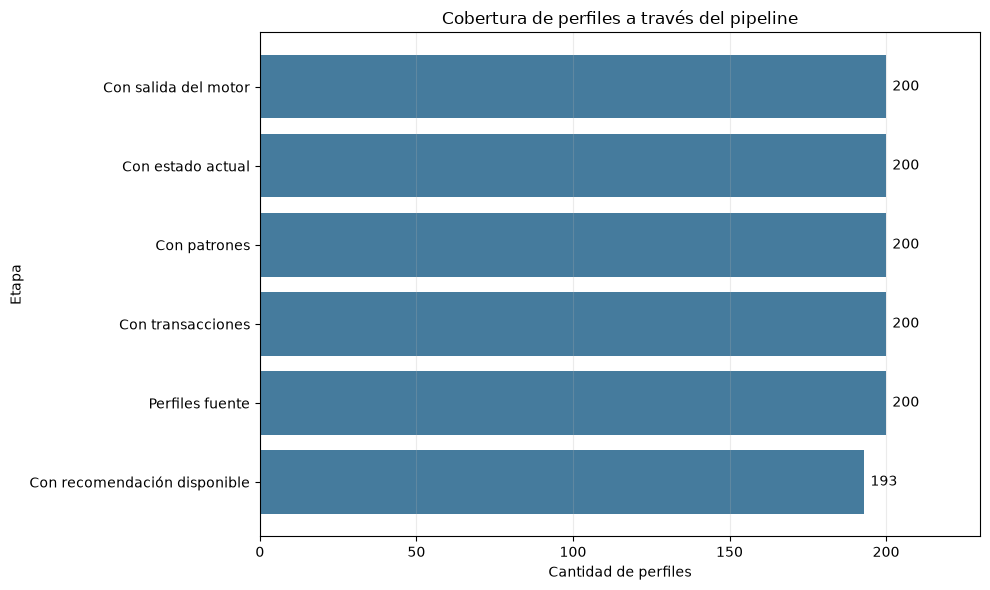

In [19]:
#Graficar cobertura
cobertura_pipeline = pd.Series({
    'Perfiles fuente': perfiles['perfil_id'].nunique(),
    'Con transacciones': transacciones['perfil_id'].nunique(),
    'Con patrones': recurrencias['perfil_id'].nunique(),
    'Con estado actual': estados['perfil_id'].nunique(),
    'Con salida del motor': recomendaciones['perfil_id'].nunique(),
    'Con recomendación disponible': recomendaciones.loc[recomendaciones['estado_motor'].eq('recomendacion_disponible'), 'perfil_id'].nunique(),
}).sort_values()

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(cobertura_pipeline.index, cobertura_pipeline.values, color='#457B9D')
eje.set_title('Cobertura de perfiles a través del pipeline')
eje.set_xlabel('Cantidad de perfiles')
eje.set_ylabel('Etapa')
eje.set_xlim(0, max(cobertura_pipeline.values) * 1.15)
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(cobertura_pipeline.values):
    eje.text(valor + 2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '06_cobertura_pipeline.png', dpi=180, bbox_inches='tight')
plt.show()

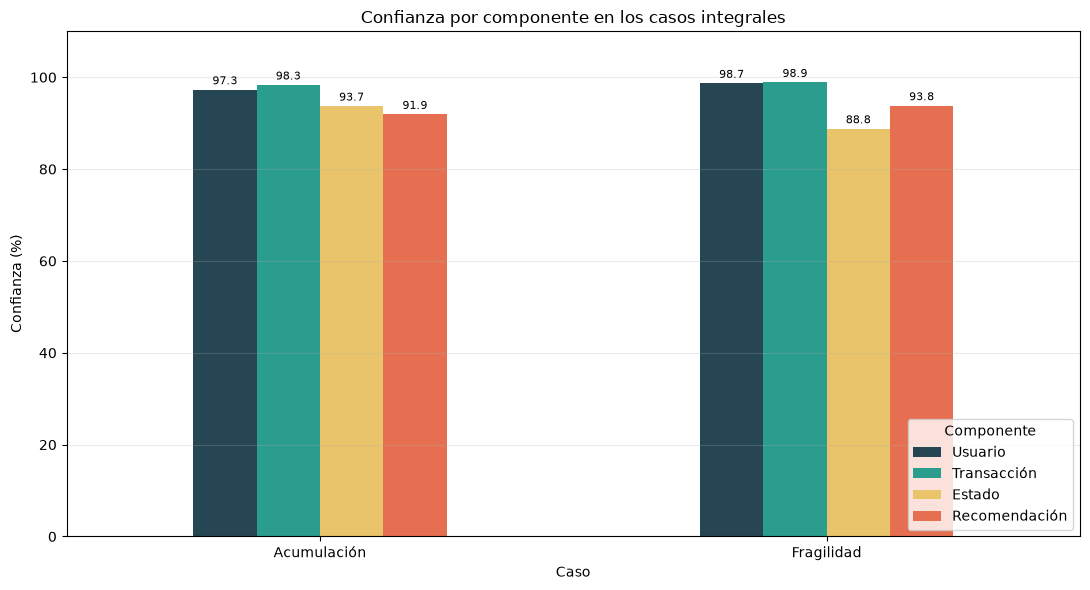

In [20]:
#Graficar confianza
confianzas_casos = pd.DataFrame([
    {
        'caso': 'Acumulación',
        'Usuario': caso_estable_exportacion['confianza_usuario_pct'],
        'Transacción': caso_estable_exportacion['confianza_transaccion_pct'],
        'Estado': caso_estable_exportacion['confianza_estado_pct'],
        'Recomendación': caso_estable_exportacion['confianza_recomendacion_pct'],
    },
    {
        'caso': 'Fragilidad',
        'Usuario': caso_vulnerable_exportacion['confianza_usuario_pct'],
        'Transacción': caso_vulnerable_exportacion['confianza_transaccion_pct'],
        'Estado': caso_vulnerable_exportacion['confianza_estado_pct'],
        'Recomendación': caso_vulnerable_exportacion['confianza_recomendacion_pct'],
    },
]).set_index('caso')

figura, eje = plt.subplots(figsize=(11, 6))
confianzas_casos.plot(kind='bar', ax=eje, color=['#264653', '#2A9D8F', '#E9C46A', '#E76F51'])
eje.set_title('Confianza por componente en los casos integrales')
eje.set_xlabel('Caso')
eje.set_ylabel('Confianza (%)')
eje.set_ylim(0, 110)
eje.tick_params(axis='x', rotation=0)
eje.grid(axis='y', alpha=0.25)
eje.legend(title='Componente', loc='lower right')

for contenedor in eje.containers:
    eje.bar_label(contenedor, fmt='%.1f', padding=2, fontsize=8)

figura.tight_layout()
figura.savefig(ruta_graficas / '06_confianza_casos_integrales.png', dpi=180, bbox_inches='tight')
plt.show()

## 10. Métricas, limitaciones y exportación

In [21]:
#Consolidar métricas
metricas_componentes = pd.concat([
    metricas_estados.assign(componente='04_estados'),
    metricas_recomendaciones.assign(componente='05_recomendaciones'),
], ignore_index=True)

limitaciones = pd.DataFrame([
    {'limitacion': 'Datos sintéticos', 'impacto': 'Las métricas no demuestran desempeño sobre población real colombiana'},
    {'limitacion': 'Catálogo profesional cerrado', 'impacto': 'Actividades no representadas deben quedar fuera del MVP'},
    {'limitacion': 'Taxonomía transaccional cerrada', 'impacto': 'Descripciones ambiguas pueden requerir confirmación'},
    {'limitacion': 'Regularidad con historial limitado', 'impacto': 'Una descripción desconocida sin movimientos anteriores debe solicitar confirmación'},
    {'limitacion': 'Catálogo cerrado de once recomendaciones', 'impacto': 'El motor selecciona opciones contextualizadas y se abstiene cuando no hay evidencia suficiente'},
    {'limitacion': 'Integración por artefactos', 'impacto': 'Los resultados temporales deben regenerarse si cambian los datos fuente'},
])

display(metricas_componentes.round(4))
display(limitaciones)

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss,particion,componente
0,bosque_aleatorio,0.9889,0.9821,0.9746,0.1423,validation,04_estados
1,regresion_logistica,0.9000,0.8708,0.8336,0.3437,validation,04_estados
2,bosque_aleatorio,0.9556,0.9524,0.9469,0.1595,test,04_estados
3,bosque_aleatorio,1.0000,1.0000,1.0000,0.1041,validation,05_recomendaciones
4,regresion_logistica,0.9882,0.9750,0.9805,0.0679,validation,05_recomendaciones
5,bosque_aleatorio,0.9540,0.9356,0.9219,0.2573,test,05_recomendaciones


,limitacion,impacto
0,Datos sintéticos,Las métricas no demuestran desempeño sobre pob...
1,Catálogo profesional cerrado,Actividades no representadas deben quedar fuer...
2,Taxonomía transaccional cerrada,Descripciones ambiguas pueden requerir confirm...
3,Regularidad con historial limitado,Una descripción desconocida sin movimientos an...
4,Catálogo cerrado de once recomendaciones,El motor selecciona opciones contextualizadas ...
5,Integración por artefactos,Los resultados temporales deben regenerarse si...


In [22]:
#Exportar cierre
ruta_trazabilidad = ruta_resultados / '06_trazabilidad_perfiles.csv'
ruta_controles = ruta_resultados / '06_controles_pipeline.csv'
ruta_casos = ruta_resultados / '06_casos_validacion.csv'
ruta_metricas = ruta_resultados / '06_metricas_componentes.csv'

controles_finales = pd.concat([
    controles_integracion.assign(tipo='integracion'),
    controles_eticos.assign(tipo='etica'),
], ignore_index=True)

trazabilidad.to_csv(ruta_trazabilidad, index=False)
controles_finales.to_csv(ruta_controles, index=False)
casos_integrales.to_csv(ruta_casos, index=False)
metricas_componentes.to_csv(ruta_metricas, index=False)

archivos_generados = pd.DataFrame([
    {'artefacto': 'trazabilidad de perfiles', 'ruta': str(ruta_trazabilidad), 'filas': len(trazabilidad)},
    {'artefacto': 'controles del pipeline', 'ruta': str(ruta_controles), 'filas': len(controles_finales)},
    {'artefacto': 'casos de validación', 'ruta': str(ruta_casos), 'filas': len(casos_integrales)},
    {'artefacto': 'métricas consolidadas', 'ruta': str(ruta_metricas), 'filas': len(metricas_componentes)},
])

display(archivos_generados)
assert trazabilidad['recorrido_completo'].all(), 'Algún perfil no completó el recorrido por los productos disponibles'

,artefacto,ruta,filas
0,trazabilidad de perfiles,../Resultados/06_trazabilidad_perfiles.csv,200
1,controles del pipeline,../Resultados/06_controles_pipeline.csv,19
2,casos de validación,../Resultados/06_casos_validacion.csv,3
3,métricas consolidadas,../Resultados/06_metricas_componentes.csv,6


## 11. Pruebas

In [23]:
#Probar caso estable
caso_estable = recorrer_perfil('PERF_0057')
display(pd.Series(caso_estable, name='caso_estable').to_frame())

assert caso_estable['estado_alcance_usuario'] == 'dentro_del_mvp'
assert caso_estable['estado_trayectoria'] == 'acumulacion_estable'
assert caso_estable['recomendacion_id'] == 'REC_APARTAR_PARA_META'
assert caso_estable['resultado_integracion'] == 'recorrido_completo'

,caso_estable
perfil_id,PERF_0057
descripcion_usuario,Editor de video / Editora de video
actividad_esperada,diseno_audiovisual_y_edicion_de_video
actividad_modelo,diseno_audiovisual_y_edicion_de_video
confianza_usuario_pct,97.28
estado_alcance_usuario,dentro_del_mvp
transaccion_id,TX_0057_0046
descripcion_transaccion,FACTURA INTERNET
categoria_esperada,Servicios
categoria_modelo,Servicios


In [24]:
#Probar caso vulnerable
caso_vulnerable = recorrer_perfil('PERF_0152')

display(pd.Series(caso_vulnerable, name='caso_vulnerable').to_frame())

assert caso_vulnerable['estado_alcance_usuario'] == 'dentro_del_mvp'
assert caso_vulnerable['estado_trayectoria'] == 'fragilidad_sostenida'
assert caso_vulnerable['recomendacion_id'] == 'REC_PROTEGER_ESENCIALES_Y_DEUDA'
assert 'esenciales_y_deuda_protegidas' in caso_vulnerable['guardas_aplicadas']

,caso_vulnerable
perfil_id,PERF_0152
descripcion_usuario,Nutricionista dietista
actividad_esperada,nutricion_y_dietetica
actividad_modelo,nutricion_y_dietetica
confianza_usuario_pct,98.68
estado_alcance_usuario,dentro_del_mvp
transaccion_id,TX_0152_0053
descripcion_transaccion,FACTURA ENERGIA
categoria_esperada,Servicios
categoria_modelo,Servicios


In [25]:
#Probar caso fuera del MVP
caso_fuera_mvp = evaluar_fuera_mvp(test_usuario_fuera)
display(pd.Series(caso_fuera_mvp, name='caso_fuera_mvp').to_frame())

assert caso_fuera_mvp['estado_alcance_usuario'] == 'no_disponible'
assert caso_fuera_mvp['etapa_detencion'] == '01_conocimiento_usuario'
assert caso_fuera_mvp['clasificacion_transaccion'] == 'no_evaluada'
assert caso_fuera_mvp['recomendacion_id'] == 'no_disponible'
assert caso_fuera_mvp['resultado_integracion'] == 'abstencion_correcta'

,caso_fuera_mvp
perfil_id,caso_manual_fuera_mvp
descripcion_usuario,Mecánico automotriz
actividad_modelo,no_disponible
confianza_usuario_pct,13.25
estado_alcance_usuario,no_disponible
etapa_detencion,01_conocimiento_usuario
clasificacion_transaccion,no_evaluada
estado_trayectoria,no_evaluado
recomendacion_id,no_disponible
resultado_integracion,abstencion_correcta


In [26]:
#Probar regularidad integrada
perfil_prueba = perfiles.loc[perfiles['perfil_id'].eq('PERF_0057')].iloc[0]
usuario_prueba = construir_test_usuario(perfil_prueba)
test_supermercado = {
    'descripcion': 'SUPERMERCADO',
    'valor': 280000,
    'direccion': 'salida',
    'ocurrencias_previas_90d': 8,
    'meses_previos_con_movimiento': 2,
    'dias_desde_movimiento_similar': 7,
    'variacion_valor_previa_pct': 18,
    'historial_regularidad_disponible': 'si',
}
test_lego = {
    'descripcion': 'LEGO',
    'valor': 180000,
    'direccion': 'salida',
    'historial_regularidad_disponible': 'no',
}
resultado_supermercado = clasificar_transaccion(usuario_prueba, test_supermercado)
resultado_lego = clasificar_transaccion(usuario_prueba, test_lego)
resultados_regularidad_integrada = pd.DataFrame([
    {'caso': 'supermercado_recurrente', **resultado_supermercado},
    {'caso': 'descripcion_fuera_del_catalogo', **resultado_lego},
])

display(resultados_regularidad_integrada[[
    'caso',
    'regularidad_movimiento',
    'confianza_regularidad_pct',
    'historial_regularidad_disponible',
    'descripcion_regularidad_conocida',
    'requiere_confirmacion_regularidad',
]])
assert resultado_supermercado['regularidad_movimiento'] == 'variable'
assert resultado_supermercado['requiere_confirmacion_regularidad'] == 'no'
assert resultado_lego['confianza_regularidad_pct'] <= 49
assert resultado_lego['requiere_confirmacion_regularidad'] == 'si'

,caso,regularidad_movimiento,confianza_regularidad_pct,historial_regularidad_disponible,descripcion_regularidad_conocida,requiere_confirmacion_regularidad
0,supermercado_recurrente,variable,99.97,si,si,no
1,descripcion_fuera_del_catalogo,variable,49.00,no,no,si
